In [20]:
import warnings
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

# plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

## 1. Data Loading and Preprocessing


In [31]:
device = "kria_openssl"
device = "kria_swtpm"
device = "kria_tpm"
device = "rpi_openssl"
device = "rpi_swtpm"
# device = "ubuntu_openssl"
# device = "ubuntu_swtpm"

results_path = "./data/{device}/results_{i}.csv"
telemetry_df = pd.read_csv(f"./data/{device}/resource_usage.csv")
telemetry_df["timestamp"] = pd.to_datetime(telemetry_df["timestamp"])

results_df_list = []
run_times = {}

# read and preprocess results
for i in range(1, 6):
    df = pd.read_csv(results_path.format(device=device, i=i))
    df["run"] = i

    df["integrity_start"] = pd.to_datetime(df["integrity_start"])
    df["integrity_end"] = pd.to_datetime(df["integrity_end"])
    df["inference_start"] = pd.to_datetime(df["inference_start"])
    df["inference_end"] = pd.to_datetime(df["inference_end"])

    df["processing_time_ms"] = df["integrity_duration_ms"] + df["inference_duration_ms"]

    # wi = with integrity check
    # woi = without integrity check
    run_times[i] = {}
    run_times[i]["wi_start"] = df[df["integrity_check_enabled"] == True]["inference_end"].min().to_datetime64()
    run_times[i]["wi_end"] = df[df["integrity_check_enabled"] == True]["inference_end"].max().to_datetime64()

    run_times[i]["woi_start"] = df[df["integrity_check_enabled"] == False]["inference_end"].min().to_datetime64()
    run_times[i]["woi_end"] = df[df["integrity_check_enabled"] == False]["inference_end"].max().to_datetime64()

    df["inference_end"].min().to_datetime64()

    results_df_list.append(df)
    del df

results_df: pd.DataFrame = pd.concat(results_df_list).sort_values(
    by=["run", "image_name", "integrity_check_enabled"], ignore_index=True
)

print("Inference DataFrame shape:", results_df.shape)
# print("Inference columns:", results_df.info())
print("Inference start   :", results_df["integrity_start"].min().to_datetime64())
print("Inference end     :", results_df["inference_end"].max().to_datetime64())
print("\nTelemetry DataFrame shape:", telemetry_df.shape)
# print("Telemetry columns :", telemetry_df.info())
print("Telemetry start   :", telemetry_df["timestamp"].min().to_datetime64())
print("Telemetry end     :", telemetry_df["timestamp"].max().to_datetime64())
print("\nRun times:")
pprint(run_times, sort_dicts=False)

Inference DataFrame shape: (420, 12)
Inference start   : 2025-07-24T12:12:18.488097000
Inference end     : 2025-07-24T12:26:44.223571000

Telemetry DataFrame shape: (94131, 4)
Telemetry start   : 2025-07-24T12:12:00.983000000
Telemetry end     : 2025-07-24T12:27:42.276000000

Run times:
{1: {'wi_start': numpy.datetime64('2025-07-24T12:12:19.493778000'),
     'wi_end': numpy.datetime64('2025-07-24T12:12:53.813637000'),
     'woi_start': numpy.datetime64('2025-07-24T12:13:54.620182000'),
     'woi_end': numpy.datetime64('2025-07-24T12:14:23.805272000')},
 2: {'wi_start': numpy.datetime64('2025-07-24T12:15:24.740168000'),
     'wi_end': numpy.datetime64('2025-07-24T12:15:58.840999000'),
     'woi_start': numpy.datetime64('2025-07-24T12:16:59.615564000'),
     'woi_end': numpy.datetime64('2025-07-24T12:17:28.973530000')},
 3: {'wi_start': numpy.datetime64('2025-07-24T12:18:29.869682000'),
     'wi_end': numpy.datetime64('2025-07-24T12:19:04.011294000'),
     'woi_start': numpy.datetime64('

In [3]:
# save integrity, inference and total processing time in a CSV file
from os import makedirs

makedirs("./data/processed", exist_ok=True)

results_df[
    [
        "run",
        "image_name",
        "integrity_check_enabled",
        "integrity_duration_ms",
        "inference_duration_ms",
        "processing_time_ms",
    ]
].to_csv(f"./data/processed/{device}.csv", index=False)

In [4]:
print(len(results_df.index))
print(len(results_df.index.unique()))
print(results_df.index.unique())

420
420
RangeIndex(start=0, stop=420, step=1)


In [5]:
print("\n=== Results Data Overview ===")
print(results_df.sample(5))


=== Results Data Overview ===
    image_name                  integrity_start                    integrity_end  integrity_duration_ms integrity_result  integrity_check_enabled                  inference_start                    inference_end  inference_duration_ms                                   inference_result  run  processing_time_ms
292     28.jpg 2025-07-24 12:23:23.391977+00:00 2025-07-24 12:23:23.391977+00:00                  0.000            VALID                    False 2025-07-24 12:23:23.391995+00:00 2025-07-24 12:23:24.243891+00:00                851.896                            n02403003 ox (98.1583)%    4             851.896
359      2.jpg 2025-07-24 12:25:03.890418+00:00 2025-07-24 12:25:04.008037+00:00                117.619            VALID                     True 2025-07-24 12:25:04.008057+00:00 2025-07-24 12:25:04.217476+00:00                209.419  n01614925 bald eagle, American eagle, Haliaeet...    5             327.038
201     24.jpg 2025-07-24 12:18:53.0

In [6]:
print("\n=== Telemetry Data Overview ===")
print(telemetry_df.sample(5))


=== Telemetry Data Overview ===
                    timestamp  cpu_usage_percent  memory_used_mb  memory_usage_percent
10897 2025-07-24 12:13:49.946               0.00             417                 11.02
75963 2025-07-24 12:24:40.606              70.86             481                 12.71
53377 2025-07-24 12:20:54.746               0.00             480                 12.68
21955 2025-07-24 12:15:40.526              63.52             513                 13.53
73477 2025-07-24 12:24:15.747               0.00             508                 13.42


In [7]:
integrity_df = results_df[results_df["integrity_check_enabled"] == True]
inference_df = results_df[results_df["integrity_check_enabled"] == False]

print(f"Images processed with integrity check    : {len(integrity_df)}")
print(f"Images processed without integrity check : {len(inference_df)}\n")

Images processed with integrity check    : 210
Images processed without integrity check : 210



## 2. Performance Comparison: With vs Without Integrity Check


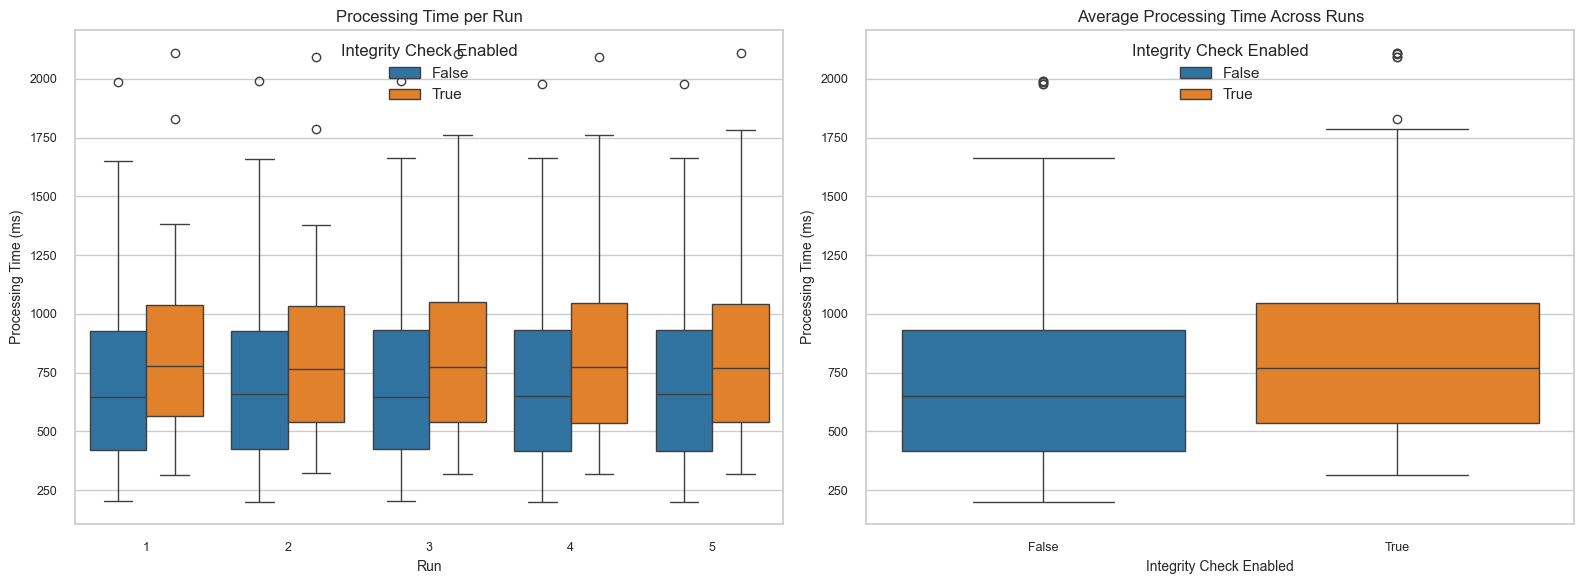

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# processing time per run
sns.boxplot(
    data=results_df, x="run", y="processing_time_ms", hue="integrity_check_enabled", palette="tab10", ax=axes[0]
)
axes[0].set_title("Processing Time per Run", fontsize=12)
axes[0].set_xlabel("Run", fontsize=10)
axes[0].set_ylabel("Processing Time (ms)", fontsize=10)
axes[0].legend(title="Integrity Check Enabled")

# avg processing time across runs
sns.boxplot(
    data=results_df,
    x="integrity_check_enabled",
    y="processing_time_ms",
    hue="integrity_check_enabled",
    palette="tab10",
    ax=axes[1],
)
axes[1].set_title("Average Processing Time Across Runs", fontsize=12)
axes[1].set_xlabel("Integrity Check Enabled", fontsize=10)
axes[1].set_ylabel("Processing Time (ms)", fontsize=10)
axes[1].legend(title="Integrity Check Enabled")

# uniform tick labels
for ax in axes:
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.show()

In [9]:
print("=== Summary per Run ===")
summary_stats = results_df.groupby("run").agg(
    {
        "integrity_duration_ms": ["mean", "std", "min", "max"],
        "inference_duration_ms": ["mean", "std", "min", "max"],
        "processing_time_ms": ["mean", "std", "min", "max"],
    }
)
summary_stats

=== Summary per Run ===


integrity_duration_ms                          inference_duration_ms                                processing_time_ms                               
                     mean        std  min      max                  mean         std      min       max               mean         std      min       max
run                                                                                                                                                      
1               59.515774  60.354339  0.0  187.457            716.980012  375.856222  198.349  1992.017         776.495786  381.559353  204.510  2109.788
2               59.585321  60.444453  0.0  189.067            715.189762  375.021260  201.287  1992.388         774.775083  379.721641  201.287  2093.169
3               59.294167  59.853538  0.0  162.902            714.677060  374.540461  201.080  1993.099         773.971226  379.243591  202.478  2104.038
4               59.537226  60.320492  0.0  183.437            713.450964  374.740807  200.051  1977.557         772.988190  379.688262  200.051  2091.775
5               59.588917  60.445530  0.0  188.900            714.590238  376.046671  201.318  1993.567         774.179155  380.666556  201.318  2111.108

In [10]:
print("=== Summary Across Runs ===")
summary_stats = results_df.groupby("integrity_check_enabled").agg(
    {
        "integrity_duration_ms": ["mean", "std", "min", "max"],
        "inference_duration_ms": ["mean", "std", "min", "max"],
        "processing_time_ms": ["mean", "std", "min", "max"],
    }
)
summary_stats

=== Summary Across Runs ===


integrity_duration_ms                              inference_duration_ms                                processing_time_ms                               
                                         mean        std      min      max                  mean         std      min       max               mean         std      min       max
integrity_check_enabled                                                                                                                                                          
False                                0.000000   0.000000    0.000    0.000            714.623948  374.219877  200.051  1993.099         714.623948  374.219877  200.051  1993.099
True                               119.008562  10.039724  116.609  189.067            715.331267  373.568230  198.349  1993.567         834.339829  373.839652  316.133  2111.108

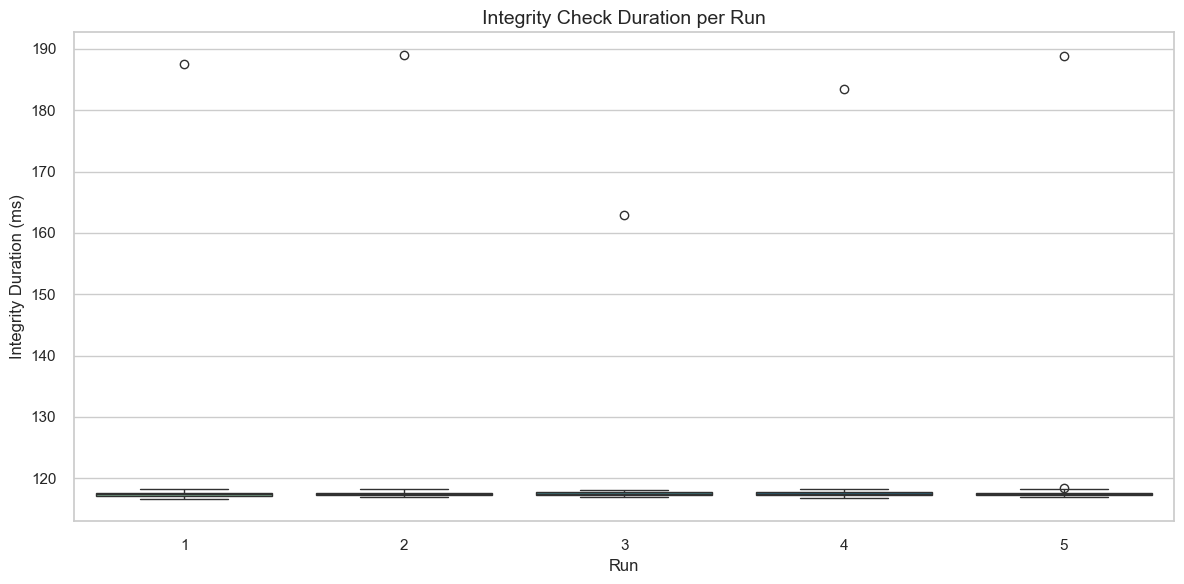

In [11]:
integrity_df = results_df[results_df["integrity_check_enabled"] == True]

plt.figure(figsize=(12, 6))
sns.boxplot(data=integrity_df, x="run", y="integrity_duration_ms", palette="crest")

plt.title("Integrity Check Duration per Run", fontsize=14)
plt.xlabel("Run", fontsize=12)
plt.ylabel("Integrity Duration (ms)", fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
# total processing time for each image
results_df["total_processing_time"] = (
    results_df["inference_end"] - results_df["integrity_start"]
).dt.total_seconds() * 1000  # Convert to milliseconds

# for images without integrity check, total time is just inference time
filter_without_integrity = results_df["integrity_check_enabled"] == False
results_df.loc[filter_without_integrity, "total_processing_time"] = results_df.loc[
    filter_without_integrity, "inference_duration_ms"
]

summary_stats = results_df.groupby("integrity_check_enabled").agg(
    {
        "integrity_duration_ms": ["mean", "std", "min", "max"],
        "inference_duration_ms": ["mean", "std", "min", "max"],
        "total_processing_time": ["mean", "std", "min", "max"],
    }
)
print(summary_stats)

                        integrity_duration_ms                              inference_duration_ms                                total_processing_time                               
                                         mean        std      min      max                  mean         std      min       max                  mean         std      min       max
integrity_check_enabled                                                                                                                                                             
False                                0.000000   0.000000    0.000    0.000            714.623948  374.219877  200.051  1993.099            714.623948  374.219877  200.051  1993.099
True                               119.008562  10.039724  116.609  189.067            715.331267  373.568230  198.349  1993.567            834.359810  373.839607  316.153  2111.128


In [13]:
summary_stats.to_excel("summary_stats.xlsx")

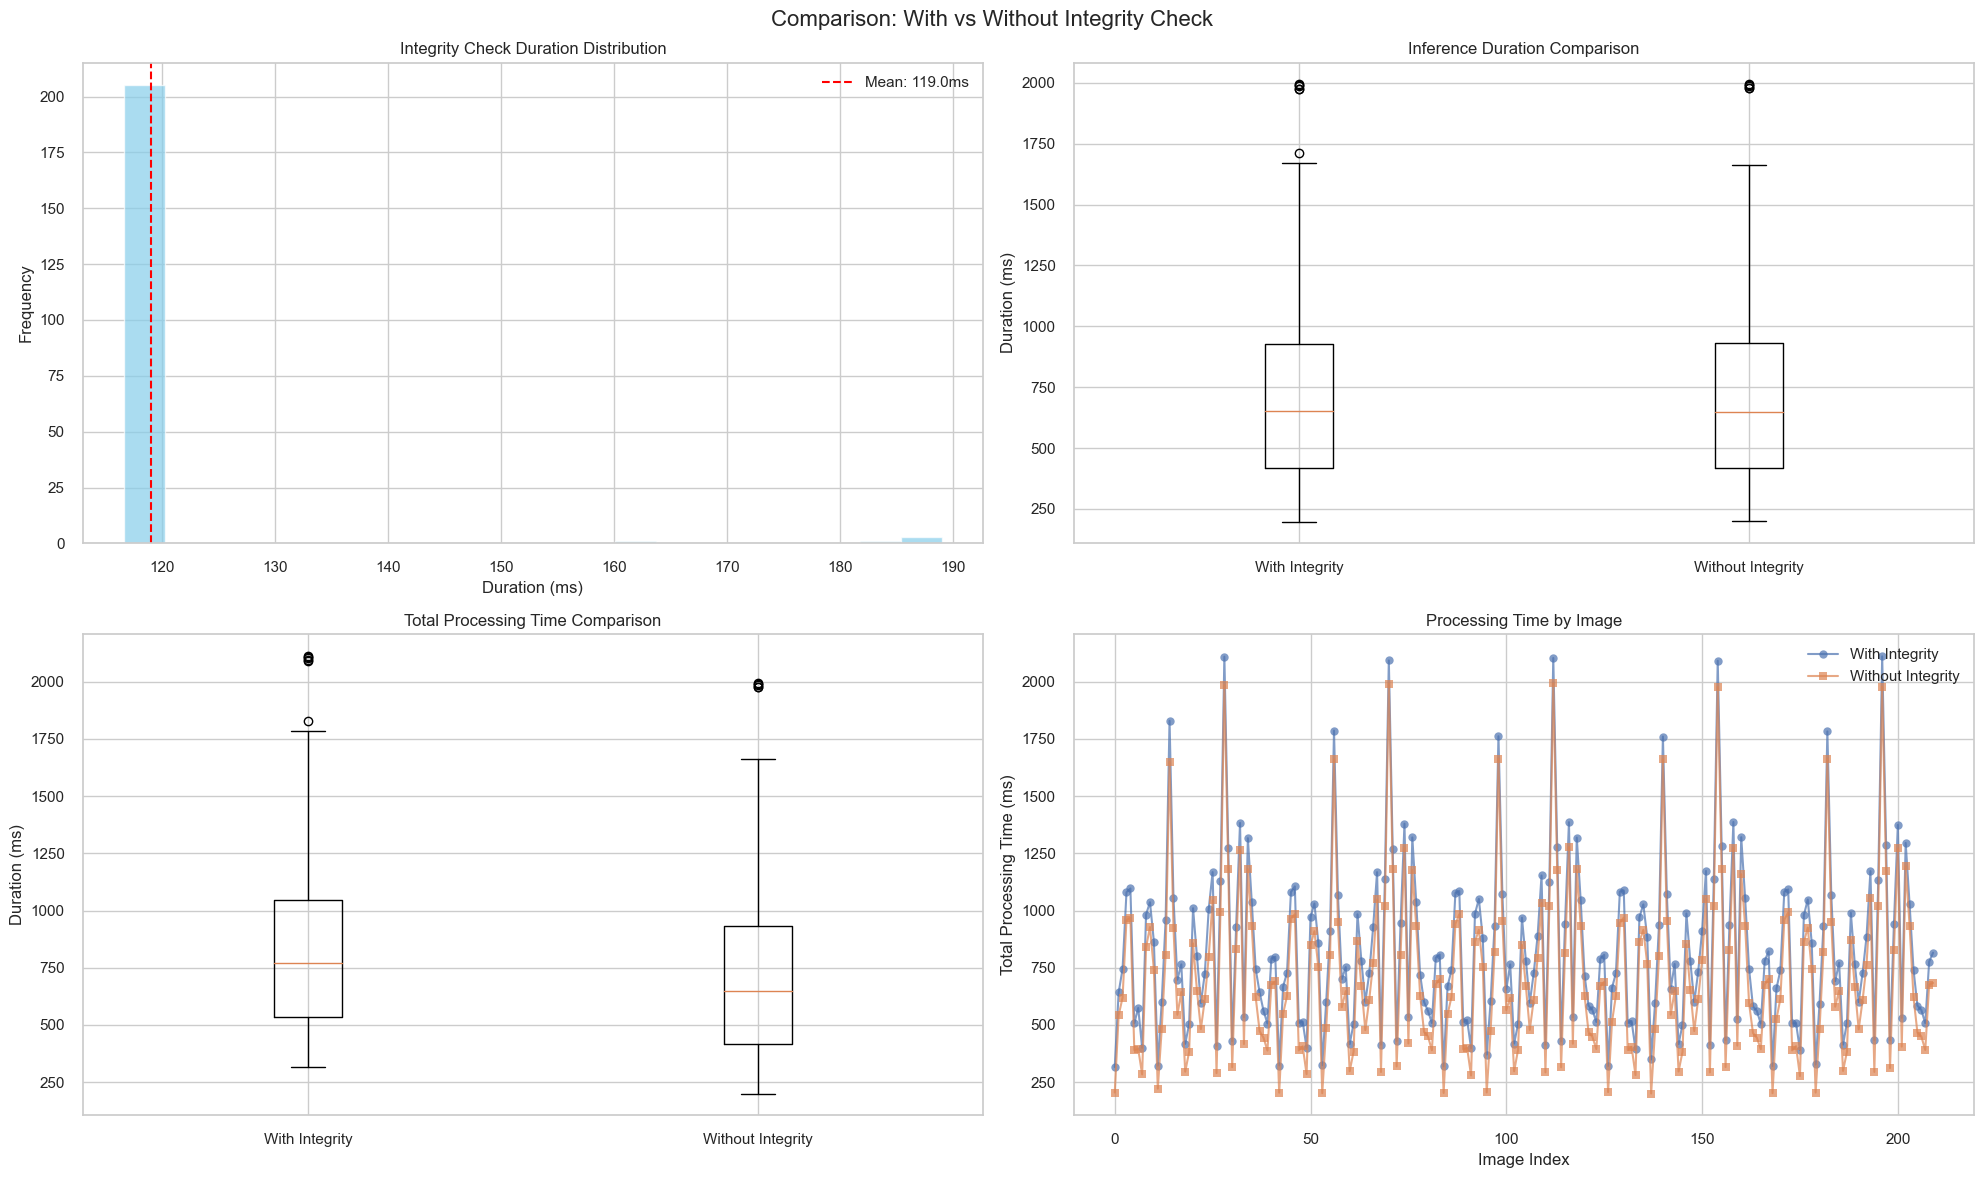

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle("Comparison: With vs Without Integrity Check", fontsize=16)

with_integrity = results_df[results_df["integrity_check_enabled"] == True]
without_integrity = results_df[results_df["integrity_check_enabled"] == False]

# total processing time
with_integrity_total = (with_integrity["inference_end"] - with_integrity["integrity_start"]).dt.total_seconds() * 1000
without_integrity_total = without_integrity["inference_duration_ms"]

# plot 1: integrity check duration distribution
with_integrity["integrity_duration_ms"].hist(ax=axes[0, 0], bins=20, alpha=0.7, color="skyblue")
axes[0, 0].set_title("Integrity Check Duration Distribution")
axes[0, 0].set_xlabel("Duration (ms)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(
    with_integrity["integrity_duration_ms"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {with_integrity['integrity_duration_ms'].mean():.1f}ms",
)
axes[0, 0].legend()

# plot 2: inference duration comparison
inference_data = [
    with_integrity["inference_duration_ms"],
    without_integrity["inference_duration_ms"],
]
axes[0, 1].boxplot(inference_data, labels=["With Integrity", "Without Integrity"])
axes[0, 1].set_title("Inference Duration Comparison")
axes[0, 1].set_ylabel("Duration (ms)")

# plot 3: total processing time comparison
total_data = [with_integrity_total, without_integrity_total]
axes[1, 0].boxplot(total_data, labels=["With Integrity", "Without Integrity"])
axes[1, 0].set_title("Total Processing Time Comparison")
axes[1, 0].set_ylabel("Duration (ms)")

# plot 4: processing time by image
axes[1, 1].plot(
    range(len(with_integrity)),
    with_integrity_total,
    "o-",
    label="With Integrity",
    alpha=0.7,
)
axes[1, 1].plot(
    range(len(without_integrity)),
    without_integrity_total,
    "s-",
    label="Without Integrity",
    alpha=0.7,
)
axes[1, 1].set_title("Processing Time by Image")
axes[1, 1].set_xlabel("Image Index")
axes[1, 1].set_ylabel("Total Processing Time (ms)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 3. CPU and Memory Usage Analysis


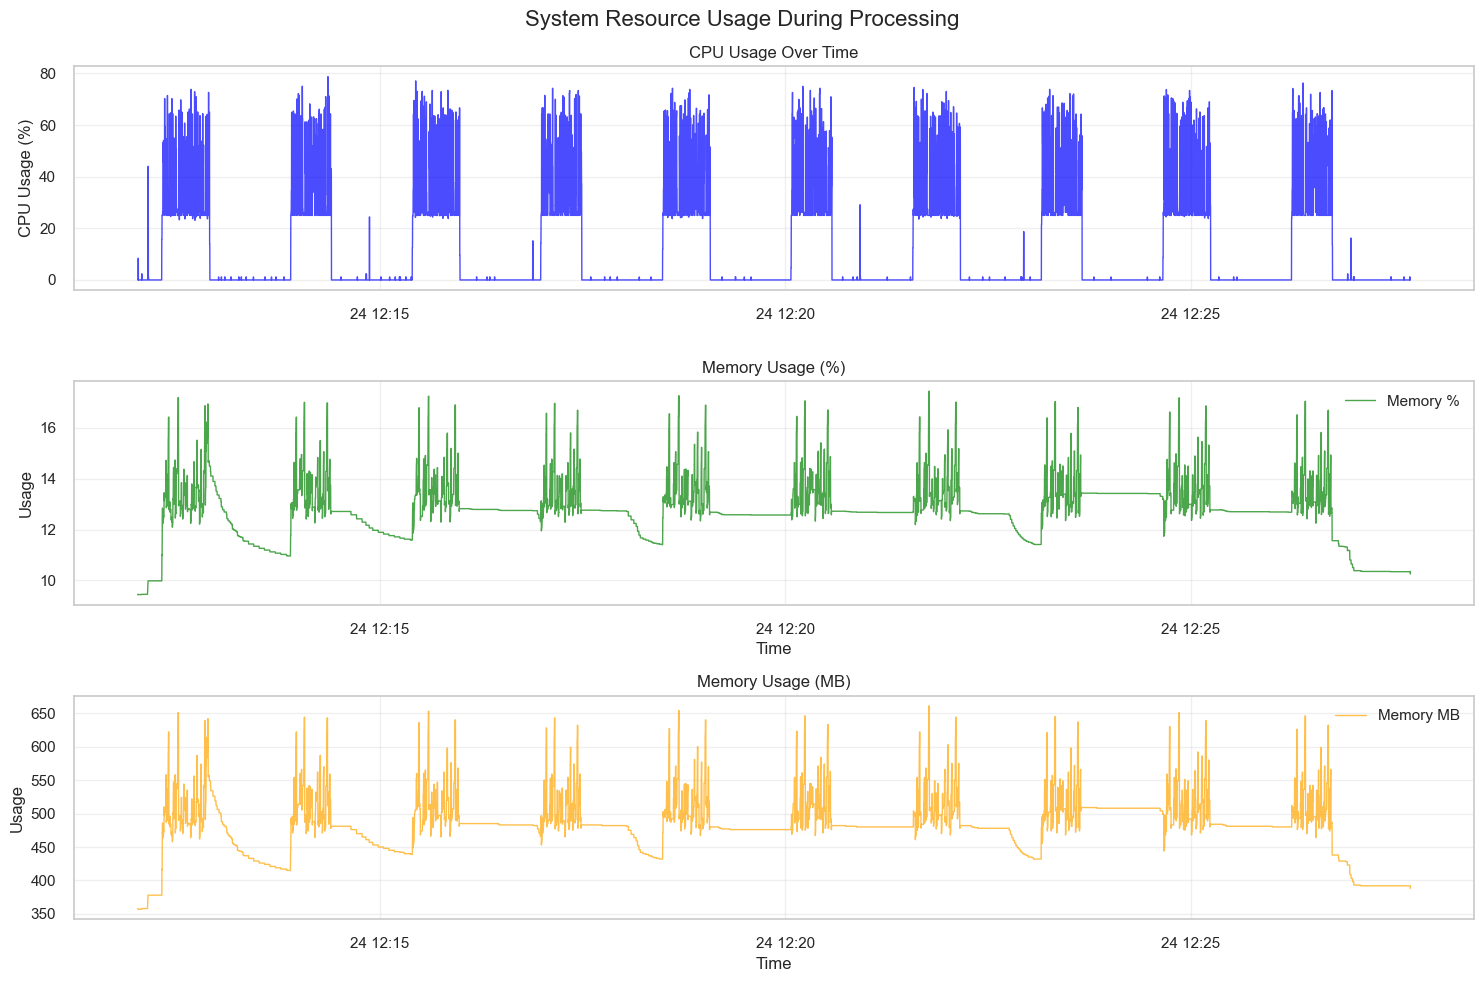

In [15]:
# time series plots for CPU and memory usage
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle("System Resource Usage During Processing", fontsize=16)

# CPU Usage
axes[0].plot(
    telemetry_df["timestamp"],
    telemetry_df["cpu_usage_percent"],
    color="blue",
    alpha=0.7,
    linewidth=1,
)
axes[0].set_title("CPU Usage Over Time")
axes[0].set_ylabel("CPU Usage (%)")
axes[0].grid(True, alpha=0.3)

# memory Usage
axes[1].plot(
    telemetry_df["timestamp"],
    telemetry_df["memory_usage_percent"],
    color="green",
    alpha=0.7,
    linewidth=1,
    label="Memory %",
)
axes[1].set_title("Memory Usage (%)")
axes[1].set_ylabel("Usage")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    telemetry_df["timestamp"],
    telemetry_df["memory_used_mb"],
    color="orange",
    alpha=0.7,
    linewidth=1,
    label="Memory MB",
)
axes[2].set_title("Memory Usage (MB)")
axes[2].set_ylabel("Usage")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# === OLD RUN EVALUATION CODE ===

# split telemetry data into two runs
run1_start = with_integrity["inference_end"].min().to_datetime64()
run1_end = with_integrity["inference_end"].max().to_datetime64()
run2_start = without_integrity["inference_end"].min().to_datetime64()
run2_end = without_integrity["inference_end"].max().to_datetime64()

run1_telemetry = telemetry_df[(telemetry_df["timestamp"] >= run1_start) & (telemetry_df["timestamp"] <= run1_end)]
run2_telemetry = telemetry_df[(telemetry_df["timestamp"] >= run2_start) & (telemetry_df["timestamp"] <= run2_end)]

print(f"Run 1 (with integrity): {len(run1_telemetry)} rows")
print(f"Run 2 (without integrity): {len(run2_telemetry)} rows")

pprint(run_times, sort_dicts=False)

Run 1 (with integrity): 77464 rows
Run 2 (without integrity): 76960 rows
{1: {'wi_start': numpy.datetime64('2025-07-24T12:12:19.493778000'),
     'wi_end': numpy.datetime64('2025-07-24T12:12:53.813637000'),
     'woi_start': numpy.datetime64('2025-07-24T12:13:54.620182000'),
     'woi_end': numpy.datetime64('2025-07-24T12:14:23.805272000')},
 2: {'wi_start': numpy.datetime64('2025-07-24T12:15:24.740168000'),
     'wi_end': numpy.datetime64('2025-07-24T12:15:58.840999000'),
     'woi_start': numpy.datetime64('2025-07-24T12:16:59.615564000'),
     'woi_end': numpy.datetime64('2025-07-24T12:17:28.973530000')},
 3: {'wi_start': numpy.datetime64('2025-07-24T12:18:29.869682000'),
     'wi_end': numpy.datetime64('2025-07-24T12:19:04.011294000'),
     'woi_start': numpy.datetime64('2025-07-24T12:20:04.806334000'),
     'woi_end': numpy.datetime64('2025-07-24T12:20:34.090564000')},
 4: {'wi_start': numpy.datetime64('2025-07-24T12:21:35.005968000'),
     'wi_end': numpy.datetime64('2025-07-24T12

In [17]:
wi_telemetry_list = []
woi_telemetry_list = []

for run_id, times in run_times.items():
    print(f"Run {run_id}:")
    print(f"  With Integrity Check    :: Start: {times['wi_start']}, End: {times['wi_end']}")
    print(f"  Without Integrity Check :: Start: {times['woi_start']}, End: {times['woi_end']}")

    wi_data = telemetry_df[
        (telemetry_df["timestamp"] >= times["wi_start"]) & (telemetry_df["timestamp"] <= times["wi_end"])
    ]
    wi_telemetry_list.append(wi_data)

    woi_data = telemetry_df[
        (telemetry_df["timestamp"] >= times["woi_start"]) & (telemetry_df["timestamp"] <= times["woi_end"])
    ]
    woi_telemetry_list.append(woi_data)

# concatenate telemetry for all runs
wi_telemetry_all = pd.concat(wi_telemetry_list, ignore_index=True)
woi_telemetry_all = pd.concat(woi_telemetry_list, ignore_index=True)

print(f"\nTotal WI telemetry rows: {len(wi_telemetry_all)}")
print(f"Total WOI telemetry rows: {len(woi_telemetry_all)}")

Run 1:
  With Integrity Check    :: Start: 2025-07-24T12:12:19.493778000, End: 2025-07-24T12:12:53.813637000
  Without Integrity Check :: Start: 2025-07-24T12:13:54.620182000, End: 2025-07-24T12:14:23.805272000
Run 2:
  With Integrity Check    :: Start: 2025-07-24T12:15:24.740168000, End: 2025-07-24T12:15:58.840999000
  Without Integrity Check :: Start: 2025-07-24T12:16:59.615564000, End: 2025-07-24T12:17:28.973530000
Run 3:
  With Integrity Check    :: Start: 2025-07-24T12:18:29.869682000, End: 2025-07-24T12:19:04.011294000
  Without Integrity Check :: Start: 2025-07-24T12:20:04.806334000, End: 2025-07-24T12:20:34.090564000
Run 4:
  With Integrity Check    :: Start: 2025-07-24T12:21:35.005968000, End: 2025-07-24T12:22:09.129316000
  Without Integrity Check :: Start: 2025-07-24T12:23:09.913797000, End: 2025-07-24T12:23:39.114270000
Run 5:
  With Integrity Check    :: Start: 2025-07-24T12:24:40.006100000, End: 2025-07-24T12:25:14.129863000
  Without Integrity Check :: Start: 2025-07-24T

In [34]:
print("=== System Resource ===")
print(f"Average CPU usage with integrity: {wi_telemetry_all['cpu_usage_percent'].mean():.2f}%")
print(f"Average CPU usage without integrity: {woi_telemetry_all['cpu_usage_percent'].mean():.2f}%")
print(f"Average memory usage with integrity: {wi_telemetry_all['memory_usage_percent'].mean():.2f}%")
print(f"Average memory usage without integrity: {woi_telemetry_all['memory_usage_percent'].mean():.2f}%")

# peak resource usage
print("\n=== Peak Resource Usage ===")
print(f"Peak CPU with integrity: {wi_telemetry_all['cpu_usage_percent'].max():.2f}%")
print(f"Peak CPU without integrity: {woi_telemetry_all['cpu_usage_percent'].max():.2f}%")
print(f"Peak memory with integrity: {wi_telemetry_all['memory_usage_percent'].max():.2f}%")
print(f"Peak memory without integrity: {woi_telemetry_all['memory_usage_percent'].max():.2f}%")

=== System Resource ===
Average CPU usage with integrity: 37.54%
Average CPU usage without integrity: 39.60%
Average memory usage with integrity: 13.55%
Average memory usage without integrity: 13.60%

=== Peak Resource Usage ===
Peak CPU with integrity: 77.11%
Peak CPU without integrity: 78.78%
Peak memory with integrity: 17.44%
Peak memory without integrity: 17.06%


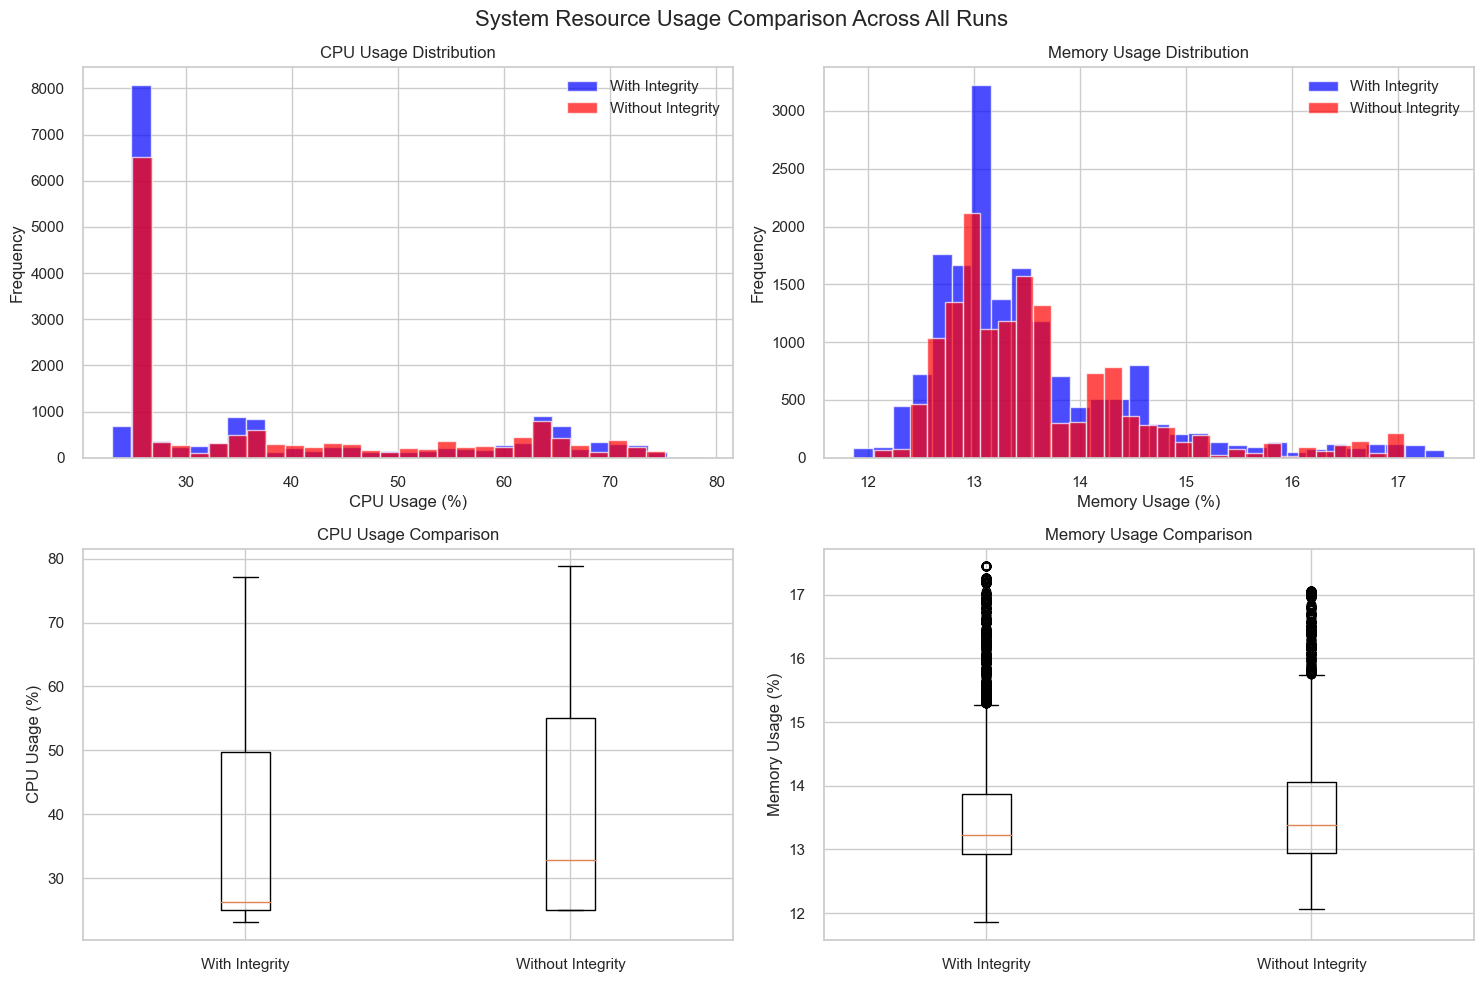

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("System Resource Usage Comparison Across All Runs", fontsize=16)

# CPU usage histograms
axes[0, 0].hist(
    wi_telemetry_all["cpu_usage_percent"],
    bins=30,
    alpha=0.7,
    label="With Integrity",
    color="blue",
)
axes[0, 0].hist(
    woi_telemetry_all["cpu_usage_percent"],
    bins=30,
    alpha=0.7,
    label="Without Integrity",
    color="red",
)
axes[0, 0].set_title("CPU Usage Distribution")
axes[0, 0].set_xlabel("CPU Usage (%)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# memory usage histograms
axes[0, 1].hist(
    wi_telemetry_all["memory_usage_percent"],
    bins=30,
    alpha=0.7,
    label="With Integrity",
    color="blue",
)
axes[0, 1].hist(
    woi_telemetry_all["memory_usage_percent"],
    bins=30,
    alpha=0.7,
    label="Without Integrity",
    color="red",
)
axes[0, 1].set_title("Memory Usage Distribution")
axes[0, 1].set_xlabel("Memory Usage (%)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

# boxplot comparison for CPU
cpu_data = [wi_telemetry_all["cpu_usage_percent"], woi_telemetry_all["cpu_usage_percent"]]
axes[1, 0].boxplot(cpu_data, labels=["With Integrity", "Without Integrity"])
axes[1, 0].set_title("CPU Usage Comparison")
axes[1, 0].set_ylabel("CPU Usage (%)")

# boxplot comparison for Memory
memory_data = [wi_telemetry_all["memory_usage_percent"], woi_telemetry_all["memory_usage_percent"]]
axes[1, 1].boxplot(memory_data, labels=["With Integrity", "Without Integrity"])
axes[1, 1].set_title("Memory Usage Comparison")
axes[1, 1].set_ylabel("Memory Usage (%)")

plt.tight_layout()
plt.show()

## 4. Summary


In [19]:
# total processing time
with_integrity_total = with_integrity["processing_time_ms"]
without_integrity_total = without_integrity["inference_duration_ms"]

# summary
print("=== Processing Time ===")
with_integrity_mean = with_integrity_total.mean()
without_integrity_mean = without_integrity_total.mean()
time_overhead = with_integrity_mean - without_integrity_mean
time_overhead_pct = (time_overhead / without_integrity_mean) * 100

print(f"Average total processing time with integrity: {with_integrity_mean:.2f} ms")
print(f"Average total processing time without integrity: {without_integrity_mean:.2f} ms")
print(f"Time overhead from integrity check: {time_overhead:.2f} ms ({time_overhead_pct:.1f}%)")
print(f"Average integrity check duration: {with_integrity['integrity_duration_ms'].mean():.2f} ms")

print("\n=== System Resource ===")
print(f"Average CPU usage with integrity: {run1_telemetry['cpu_usage_percent'].mean():.2f}%")
print(f"Average CPU usage without integrity: {run2_telemetry['cpu_usage_percent'].mean():.2f}%")
print(f"Average memory usage with integrity: {run1_telemetry['memory_usage_percent'].mean():.2f}%")
print(f"Average memory usage without integrity: {run2_telemetry['memory_usage_percent'].mean():.2f}%")

# peak resource usage
print("\n=== Peak Resource Usage ===")
print(f"Peak CPU with integrity: {run1_telemetry['cpu_usage_percent'].max():.2f}%")
print(f"Peak CPU without integrity: {run2_telemetry['cpu_usage_percent'].max():.2f}%")
print(f"Peak memory with integrity: {run1_telemetry['memory_usage_percent'].max():.2f}%")
print(f"Peak memory without integrity: {run2_telemetry['memory_usage_percent'].max():.2f}%")

=== Processing Time ===
Average total processing time with integrity: 834.34 ms
Average total processing time without integrity: 714.62 ms
Time overhead from integrity check: 119.72 ms (16.8%)
Average integrity check duration: 119.01 ms

=== System Resource ===
Average CPU usage with integrity: 14.63%
Average CPU usage without integrity: 14.56%
Average memory usage with integrity: 12.91%
Average memory usage without integrity: 12.97%

=== Peak Resource Usage ===
Peak CPU with integrity: 78.78%
Peak CPU without integrity: 78.78%
Peak memory with integrity: 17.44%
Peak memory without integrity: 17.44%
